# Stage 2 — ANN Predictive Modeling for Customer Churn
### Telecommunications Customer Churn Analysis

---

**Project Role:** Data Analyst — Predictive Modeling  
**Objective:** Build, train, and evaluate an Artificial Neural Network (ANN) to predict customer churn using the Stage 1 cleaned dataset.

**Stage 2 Deliverables:**
- ✅ Review and select an appropriate ANN architecture
- ✅ Define and configure the ANN model (input, hidden, and output layers)
- ✅ Train the ANN model and adjust hyperparameters to improve convergence
- ✅ Predict customer churn and fine-tune for better performance
- ✅ Analyse model output using Accuracy, Precision, Recall, and F1-score
- ✅ Visualise results for team discussions and presentations

---

## 📦 Section 1 — Install & Import Libraries

In [1]:
# Install required packages (run once in Colab)
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
# ── Core Libraries ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# ── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility Seed ────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print("✅ All libraries loaded successfully.")

TensorFlow version : 2.20.0
Keras version      : 3.13.2
✅ All libraries loaded successfully.


---
## 📂 Section 2 — Load & Inspect the Stage 1 Cleaned Dataset

In [3]:
# ── Upload the file when running in Google Colab ────────────────────────────
# If running locally, replace the path with your local file path.
from google.colab import files
print("Please upload 'stage1_cleaned_dataset.csv'")
uploaded = files.upload()

Please upload 'stage1_cleaned_dataset.csv'


Saving stage1_cleaned_dataset.csv to stage1_cleaned_dataset.csv


In [4]:
# ── Load Dataset ────────────────────────────────────────────────────────────
df = pd.read_csv('stage1_cleaned_dataset.csv')

print(f"Dataset shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names    : {df.columns.tolist()}")
print(f"\nMissing values  :\n{df.isnull().sum()}")
df.head(10)

Dataset shape   : 6741 rows × 18 columns

Column names    : ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'MonthlyCharges', 'Churn', 'gender_encoded', 'Dependents_encoded', 'PhoneService_encoded', 'MultipleLines_encoded', 'InternetService_encoded', 'Churn_encoded', 'Contract_Month-to-month', 'Contract_One_year', 'Contract_Two_year']

Missing values  :
gender                     0
SeniorCitizen              0
Dependents                 0
tenure                     0
PhoneService               0
MultipleLines              0
InternetService            0
MonthlyCharges             0
Churn                      0
gender_encoded             0
Dependents_encoded         0
PhoneService_encoded       0
MultipleLines_encoded      0
InternetService_encoded    0
Churn_encoded              0
Contract_Month-to-month    0
Contract_One_year          0
Contract_Two_year          0
dtype: int64


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,gender_encoded,Dependents_encoded,PhoneService_encoded,MultipleLines_encoded,InternetService_encoded,Churn_encoded,Contract_Month-to-month,Contract_One_year,Contract_Two_year
0,Female,0,No,1,No,No,DSL,25,Yes,0,0,0,0,0,1,True,False,False
1,Male,0,No,41,Yes,No,DSL,25,No,1,0,1,0,0,0,False,True,False
2,Female,0,Yes,52,Yes,No,DSL,19,No,0,1,1,0,0,0,True,False,False
3,Female,0,No,1,Yes,No,DSL,76,Yes,0,0,1,0,0,1,False,True,False
4,Male,0,No,67,Yes,No,Fiber optic,51,No,1,0,1,0,1,0,True,False,False
5,Female,1,No,68,Yes,Yes,Fiber optic,90,Yes,0,0,1,1,1,1,True,False,False
6,Female,0,Yes,23,Yes,Yes,Fiber optic,77,No,0,1,1,1,1,0,True,False,False
7,Male,0,Yes,72,Yes,No,DSL,72,No,1,1,1,0,0,0,True,False,False
8,Male,0,No,70,Yes,Yes,Fiber optic,104,Yes,1,0,1,1,1,1,True,False,False
9,Male,0,No,1,Yes,No,DSL,19,Yes,1,0,1,0,0,1,False,True,False


In [5]:
# ── Dataset Summary Statistics ──────────────────────────────────────────────
print("📊 Descriptive Statistics (Numeric Features):\n")
df.describe().T.style.background_gradient(cmap='Blues')

📊 Descriptive Statistics (Numeric Features):



,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,6741.000000,0.167631,0.373566,0.000000,0.000000,0.000000,0.000000,1.000000
tenure,6741.000000,32.945112,24.333994,0.000000,10.000000,30.000000,56.000000,72.000000
MonthlyCharges,6741.000000,65.843495,29.680059,18.000000,41.000000,71.000000,90.000000,119.000000
gender_encoded,6741.000000,0.503338,0.500026,0.000000,0.000000,1.000000,1.000000,1.000000
Dependents_encoded,6741.000000,0.304258,0.460126,0.000000,0.000000,0.000000,1.000000,1.000000
PhoneService_encoded,6741.000000,0.900163,0.299805,0.000000,1.000000,1.000000,1.000000,1.000000
MultipleLines_encoded,6741.000000,0.422193,0.493946,0.000000,0.000000,0.000000,1.000000,1.000000
InternetService_encoded,6741.000000,0.439846,0.496405,0.000000,0.000000,0.000000,1.000000,1.000000
Churn_encoded,6741.000000,0.265688,0.441731,0.000000,0.000000,0.000000,1.000000,1.000000


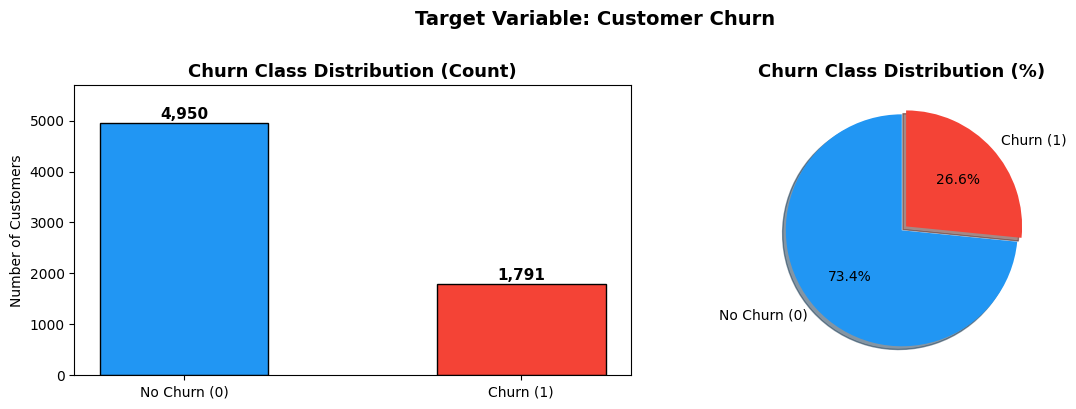


Class Balance Summary:
  No Churn : 4,950 (73.4%)
  Churn    : 1,791 (26.6%)
  Imbalance Ratio (No Churn : Churn) ≈ 2.76 : 1


In [6]:
# ── Target Class Distribution ───────────────────────────────────────────────
churn_counts = df['Churn_encoded'].value_counts()
churn_labels = ['No Churn (0)', 'Churn (1)']
churn_pct    = churn_counts / churn_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(churn_labels, churn_counts.values,
                   color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
for bar, count in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Churn Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_labels, autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90,
            explode=(0, 0.05), shadow=True)
axes[1].set_title('Churn Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass Balance Summary:")
print(f"  No Churn : {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"  Churn    : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")
print(f"  Imbalance Ratio (No Churn : Churn) ≈ {churn_counts[0]/churn_counts[1]:.2f} : 1")

---
## 🔧 Section 3 — Feature Engineering & Data Preparation

In [7]:
# ── Select Encoded Feature Columns for the Model ────────────────────────────
# We use the pre-encoded numeric features from Stage 1.
# These cover demographics, services, billing and contract type.

FEATURE_COLS = [
    'gender_encoded',
    'SeniorCitizen',
    'Dependents_encoded',
    'tenure',
    'PhoneService_encoded',
    'MultipleLines_encoded',
    'InternetService_encoded',
    'MonthlyCharges',
    'Contract_Month-to-month',
    'Contract_One_year',
    'Contract_Two_year'
]

TARGET_COL = 'Churn_encoded'

X = df[FEATURE_COLS].astype(float)
y = df[TARGET_COL].astype(int)

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nFeatures used ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

Feature matrix X : (6741, 11)
Target vector  y : (6741,)

Features used (11):
   1. gender_encoded
   2. SeniorCitizen
   3. Dependents_encoded
   4. tenure
   5. PhoneService_encoded
   6. MultipleLines_encoded
   7. InternetService_encoded
   8. MonthlyCharges
   9. Contract_Month-to-month
  10. Contract_One_year
  11. Contract_Two_year


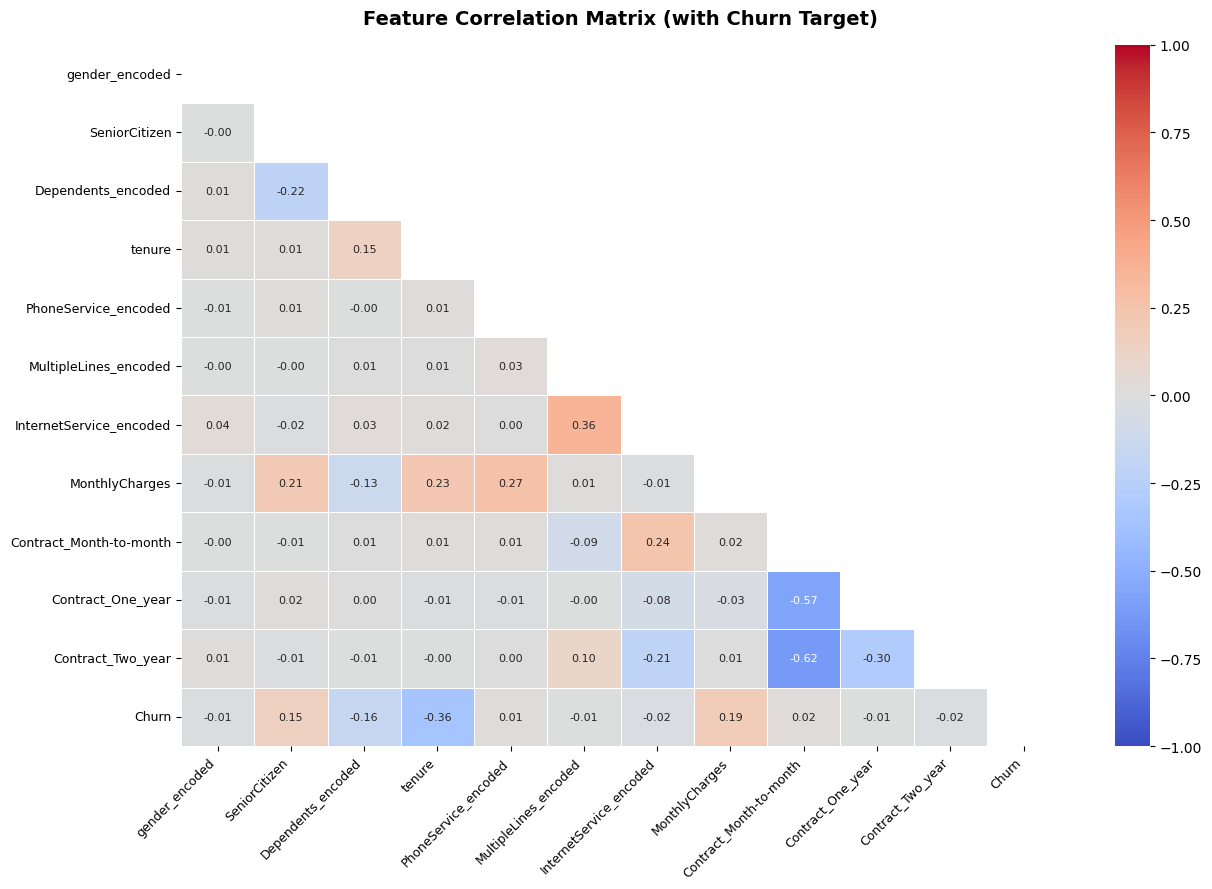

In [8]:
# ── Feature Correlation Heatmap ─────────────────────────────────────────────
corr_data = X.copy()
corr_data['Churn'] = y

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(
    corr_data.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix (with Churn Target)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Train / Validation / Test Split (70 / 15 / 15) ──────────────────────────
# Stratified splits to preserve class imbalance ratio in every split.

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Split Summary (Stratified):")
print(f"  Training   : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation : {X_val.shape[0]:,} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nChurn rate in each split:")
print(f"  Training   : {y_train.mean()*100:.1f}%")
print(f"  Validation : {y_val.mean()*100:.1f}%")
print(f"  Test       : {y_test.mean()*100:.1f}%")

Split Summary (Stratified):
  Training   : 4,718 samples  (70.0%)
  Validation : 1,011 samples  (15.0%)
  Test       : 1,012 samples  (15.0%)

Churn rate in each split:
  Training   : 26.6%
  Validation : 26.5%
  Test       : 26.6%


In [10]:
# ── Feature Scaling (StandardScaler fit on Training set only) ───────────────
# IMPORTANT: Scaler is fit ONLY on training data to prevent data leakage.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Feature Scaling Complete (StandardScaler):")
print(f"  Training mean  : {X_train_sc.mean():.6f}  (expected ≈ 0)")
print(f"  Training std   : {X_train_sc.std():.6f}   (expected ≈ 1)")

# ── Class Weight (to handle class imbalance) ─────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"\nClass Weights (to handle imbalance):")
print(f"  Class 0 (No Churn) : {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Churn)    : {class_weight_dict[1]:.4f}")

Feature Scaling Complete (StandardScaler):
  Training mean  : 0.000000  (expected ≈ 0)
  Training std   : 1.000000   (expected ≈ 1)

Class Weights (to handle imbalance):
  Class 0 (No Churn) : 0.6810
  Class 1 (Churn)    : 1.8812


---
## 🏗️ Section 4 — ANN Model Architecture Design

In [11]:
# ────────────────────────────────────────────────────────────────────────────
#  ANN ARCHITECTURE RATIONALE
# ────────────────────────────────────────────────────────────────────────────
#
#  Input Layer  : 11 neurons (one per feature after StandardScaler)
#
#  Hidden Layer 1: 64 neurons
#    - ReLU activation  → introduces non-linearity, avoids vanishing gradients
#    - BatchNormalization → stabilises training, accelerates convergence
#    - Dropout(0.3)     → regularisation against overfitting
#    - L2 regularisation → weight penalty to penalise complexity
#
#  Hidden Layer 2: 32 neurons
#    - ReLU activation
#    - BatchNormalization
#    - Dropout(0.2)
#
#  Hidden Layer 3: 16 neurons
#    - ReLU activation
#    - BatchNormalization
#
#  Output Layer : 1 neuron
#    - Sigmoid activation → outputs probability [0,1] for binary classification
#
#  Loss Function : Binary Cross-Entropy (standard for binary classification)
#  Optimiser     : Adam with learning rate 0.001
#  Metrics       : Accuracy, AUC (ROC)
# ────────────────────────────────────────────────────────────────────────────

INPUT_DIM = X_train_sc.shape[1]

def build_ann_model(input_dim, learning_rate=0.001):
    """Build and compile the ANN model."""
    model = Sequential([

        # ── Input → Hidden Layer 1 ─────────────────────────────────────────
        Dense(64, input_dim=input_dim,
              activation='relu',
              kernel_regularizer=l2(0.001),
              kernel_initializer='he_normal',
              name='hidden_layer_1'),
        BatchNormalization(name='batchnorm_1'),
        Dropout(0.3, name='dropout_1'),

        # ── Hidden Layer 2 ─────────────────────────────────────────────────
        Dense(32,
              activation='relu',
              kernel_regularizer=l2(0.001),
              kernel_initializer='he_normal',
              name='hidden_layer_2'),
        BatchNormalization(name='batchnorm_2'),
        Dropout(0.2, name='dropout_2'),

        # ── Hidden Layer 3 ─────────────────────────────────────────────────
        Dense(16,
              activation='relu',
              kernel_regularizer=l2(0.001),
              kernel_initializer='he_normal',
              name='hidden_layer_3'),
        BatchNormalization(name='batchnorm_3'),

        # ── Output Layer ───────────────────────────────────────────────────
        Dense(1,
              activation='sigmoid',
              name='output_layer')
    ], name='ANN_CustomerChurn')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ── Build the model ──────────────────────────────────────────────────────────
model = build_ann_model(INPUT_DIM)
model.summary()

Model: "ANN_CustomerChurn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,617 (14.13 KB)

 Non-trainable params: 224 (896.00 B)

In [12]:
# ── Visualise Model Architecture ─────────────────────────────────────────────
# Text-based summary of layer shapes
print("\n" + "="*60)
print("   ANN ARCHITECTURE — LAYER CONFIGURATION SUMMARY")
print("="*60)

layer_info = [
    ("INPUT LAYER",       f"{INPUT_DIM} neurons",  "—",        "Raw scaled features"),
    ("Hidden Layer 1",    "64 neurons",           "ReLU",     "BatchNorm + Dropout(0.3) + L2"),
    ("Hidden Layer 2",    "32 neurons",           "ReLU",     "BatchNorm + Dropout(0.2) + L2"),
    ("Hidden Layer 3",    "16 neurons",           "ReLU",     "BatchNorm + L2"),
    ("OUTPUT LAYER",      "1 neuron",             "Sigmoid",  "Binary churn probability"),
]

print(f"{'Layer':<18} {'Neurons':<15} {'Activation':<12} {'Regularisation'}")
print("-"*60)
for layer, neurons, act, reg in layer_info:
    print(f"{layer:<18} {neurons:<15} {act:<12} {reg}")

print("-"*60)
total_params = model.count_params()
print(f"\n  Total Trainable Parameters : {total_params:,}")
print(f"  Optimiser                  : Adam (lr=0.001)")
print(f"  Loss Function              : Binary Cross-Entropy")
print(f"  Metrics                    : Accuracy, AUC")
print("="*60)


   ANN ARCHITECTURE — LAYER CONFIGURATION SUMMARY
Layer              Neurons         Activation   Regularisation
------------------------------------------------------------
INPUT LAYER        11 neurons      —            Raw scaled features
Hidden Layer 1     64 neurons      ReLU         BatchNorm + Dropout(0.3) + L2
Hidden Layer 2     32 neurons      ReLU         BatchNorm + Dropout(0.2) + L2
Hidden Layer 3     16 neurons      ReLU         BatchNorm + L2
OUTPUT LAYER       1 neuron        Sigmoid      Binary churn probability
------------------------------------------------------------

  Total Trainable Parameters : 3,841
  Optimiser                  : Adam (lr=0.001)
  Loss Function              : Binary Cross-Entropy
  Metrics                    : Accuracy, AUC


---
## 🏋️ Section 5 — Model Training with Callbacks & Convergence Optimisation

In [13]:
# ── Training Hyperparameters ──────────────────────────────────────────────────
EPOCHS     = 150
BATCH_SIZE = 64

# ── Callbacks ────────────────────────────────────────────────────────────────
#
#  EarlyStopping       : Stops training when val_loss stops improving,
#                        restores best weights automatically.
#  ReduceLROnPlateau   : Halves the learning rate when val_loss plateaus
#                        — avoids overshooting the minimum.
#  ModelCheckpoint     : Saves the best model weights to disk.
#
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_ann_churn_model.keras',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("Training Configuration:")
print(f"  Epochs (max)        : {EPOCHS}")
print(f"  Batch Size          : {BATCH_SIZE}")
print(f"  EarlyStopping       : patience=20, monitor=val_loss")
print(f"  ReduceLROnPlateau   : patience=10, factor=0.5")
print(f"  Class Weights       : {class_weight_dict}")
print("\n🚀 Starting Training...")

Training Configuration:
  Epochs (max)        : 150
  Batch Size          : 64
  EarlyStopping       : patience=20, monitor=val_loss
  ReduceLROnPlateau   : patience=10, factor=0.5
  Class Weights       : {0: np.float64(0.6810046189376443), 1: np.float64(1.8811802232854864)}

🚀 Starting Training...


In [14]:
# ── Train the Model ───────────────────────────────────────────────────────────
history = model.fit(
    X_train_sc, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_sc, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

actual_epochs = len(history.history['loss'])
print(f"\n✅ Training complete. Ran {actual_epochs} epochs (early stopped).")
print(f"   Best val_loss : {min(history.history['val_loss']):.4f}")
print(f"   Best val_auc  : {max(history.history['val_auc']):.4f}")

Epoch 1/150
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5539 - auc: 0.5684 - loss: 1.0387
Epoch 1: val_auc improved from None to 0.77569, saving model to best_ann_churn_model.keras

Epoch 1: finished saving model to best_ann_churn_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5755 - auc: 0.6112 - loss: 0.9657 - val_accuracy: 0.6370 - val_auc: 0.7757 - val_loss: 0.8522 - learning_rate: 0.0010
Epoch 2/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6532 - auc: 0.7271 - loss: 0.8350
Epoch 2: val_auc improved from 0.77569 to 0.81699, saving model to best_ann_churn_model.keras

Epoch 2: finished saving model to best_ann_churn_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6473 - auc: 0.7174 - loss: 0.8412 - val_accuracy: 0.7280 - val_auc: 0.8170 - val_loss: 0.7741 - learning_rate: 0.0010
Epoch 3/150
70/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6901 - auc: 0.7609 - loss: 0.7943
Epoch 3: val_auc improved from 0.81699 to 0.82381, 

---
## 📈 Section 6 — Training History & Convergence Visualisation

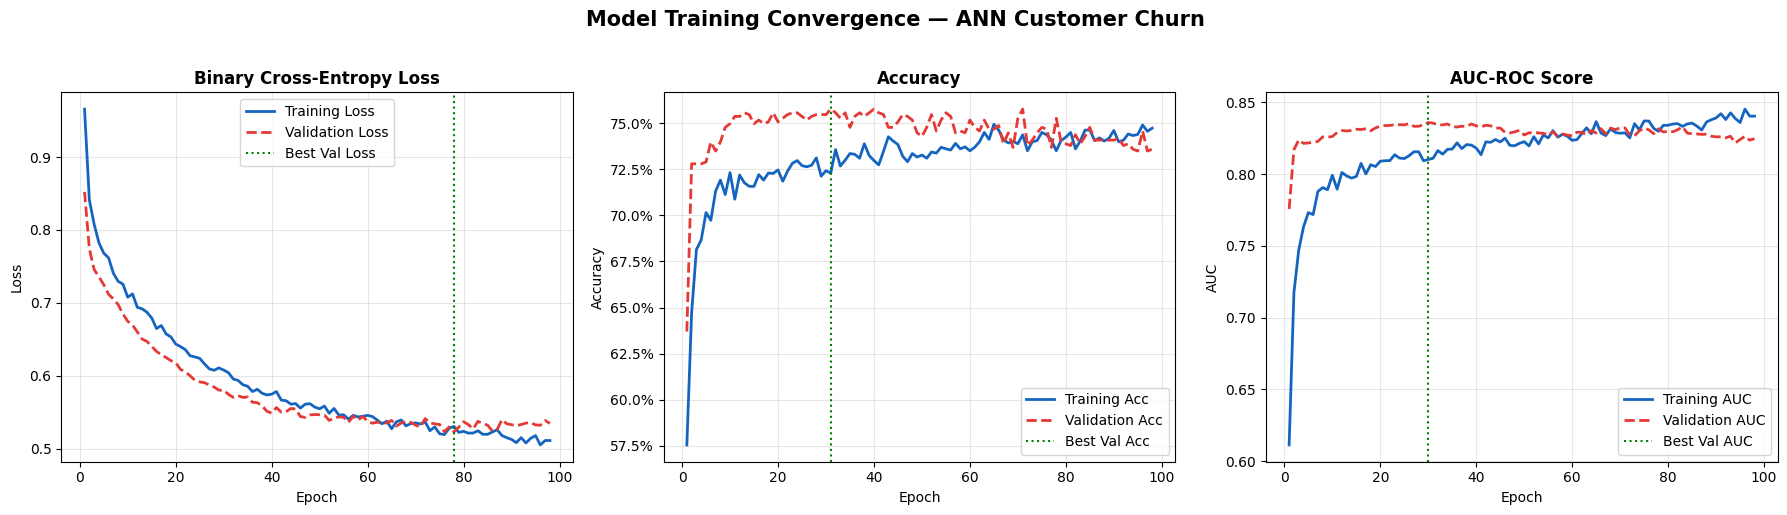

In [15]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
epochs_ran = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Training Convergence — ANN Customer Churn',
             fontsize=15, fontweight='bold', y=1.02)

# ── Loss ──────────────────────────────────────────────────────────────────────
axes[0].plot(epochs_ran, history.history['loss'],     label='Training Loss',   color='#1565C0', lw=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Validation Loss', color='#E53935', lw=2, ls='--')
axes[0].axvline(np.argmin(history.history['val_loss'])+1,
                color='green', lw=1.5, ls=':', label='Best Val Loss')
axes[0].set_title('Binary Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[1].plot(epochs_ran, history.history['accuracy'],     label='Training Acc',   color='#1565C0', lw=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Validation Acc', color='#E53935', lw=2, ls='--')
axes[1].axvline(np.argmax(history.history['val_accuracy'])+1,
                color='green', lw=1.5, ls=':', label='Best Val Acc')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── AUC ───────────────────────────────────────────────────────────────────────
axes[2].plot(epochs_ran, history.history['auc'],     label='Training AUC',   color='#1565C0', lw=2)
axes[2].plot(epochs_ran, history.history['val_auc'], label='Validation AUC', color='#E53935', lw=2, ls='--')
axes[2].axvline(np.argmax(history.history['val_auc'])+1,
                color='green', lw=1.5, ls=':', label='Best Val AUC')
axes[2].set_title('AUC-ROC Score', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔮 Section 7 — Predictions on Test Set

In [16]:
# ── Load Best Saved Model ─────────────────────────────────────────────────────
best_model = keras.models.load_model('best_ann_churn_model.keras')
print("✅ Best model loaded from checkpoint.")

# ── Get Predicted Probabilities ───────────────────────────────────────────────
y_pred_proba = best_model.predict(X_test_sc, verbose=0).flatten()

# ── Threshold Optimisation (default 0.5) ─────────────────────────────────────
# In churn prediction, we often prefer higher recall (catching churners)
# over pure accuracy. We'll evaluate at 0.5 and compare with 0.4.
THRESHOLD = 0.5
y_pred_binary = (y_pred_proba >= THRESHOLD).astype(int)

print(f"\nPrediction Summary (threshold = {THRESHOLD}):")
print(f"  Test samples          : {len(y_test):,}")
print(f"  Predicted No Churn(0) : {(y_pred_binary==0).sum():,}")
print(f"  Predicted Churn(1)    : {(y_pred_binary==1).sum():,}")
print(f"  Probability range     : [{y_pred_proba.min():.3f}, {y_pred_proba.max():.3f}]")

✅ Best model loaded from checkpoint.

Prediction Summary (threshold = 0.5):
  Test samples          : 1,012
  Predicted No Churn(0) : 610
  Predicted Churn(1)    : 402
  Probability range     : [0.021, 0.912]


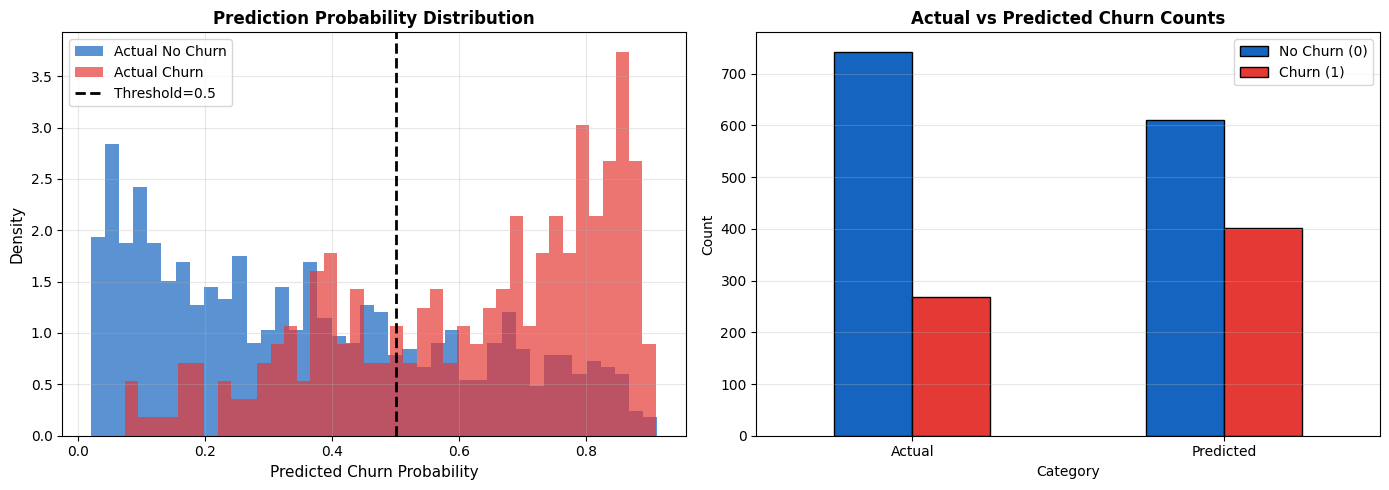

In [17]:
# ── Predicted Probability Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of prediction probabilities
axes[0].hist(y_pred_proba[y_test == 0], bins=40, alpha=0.7, label='Actual No Churn',
             color='#1565C0', density=True)
axes[0].hist(y_pred_proba[y_test == 1], bins=40, alpha=0.7, label='Actual Churn',
             color='#E53935', density=True)
axes[0].axvline(THRESHOLD, color='black', lw=2, ls='--', label=f'Threshold={THRESHOLD}')
axes[0].set_xlabel('Predicted Churn Probability', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Actual vs Predicted counts
comp_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_binary})
comp_counts = comp_df.apply(pd.value_counts).fillna(0)
comp_counts.T.plot(kind='bar', ax=axes[1], color=['#1565C0','#E53935'], edgecolor='black')
axes[1].set_title('Actual vs Predicted Churn Counts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Actual', 'Predicted'], rotation=0)
axes[1].legend(['No Churn (0)', 'Churn (1)'])
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Section 8 — Model Performance Evaluation

In [18]:
# ── Core Metrics ──────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall    = recall_score(y_test, y_pred_binary)
f1        = f1_score(y_test, y_pred_binary)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("="*55)
print("    MODEL PERFORMANCE SUMMARY — TEST SET")
print("="*55)
print(f"  {'Metric':<25} {'Value':>10}")
print("-"*55)
print(f"  {'Accuracy':<25} {accuracy:>10.4f}  ({accuracy*100:.2f}%)")
print(f"  {'Precision':<25} {precision:>10.4f}")
print(f"  {'Recall (Sensitivity)':<25} {recall:>10.4f}")
print(f"  {'F1-Score':<25} {f1:>10.4f}")
print(f"  {'ROC-AUC Score':<25} {roc_auc:>10.4f}")
print("="*55)

print(f"""
Interpretation:
  - Accuracy  : {accuracy*100:.1f}% of all customers correctly classified.
  - Precision : When the model predicts churn, it is correct {precision*100:.1f}% of the time.
  - Recall    : The model detects {recall*100:.1f}% of actual churners.
  - F1-Score  : Harmonic mean of Precision & Recall = {f1:.4f}.
  - ROC-AUC   : {roc_auc:.4f} — model has {'excellent' if roc_auc>0.85 else 'good' if roc_auc>0.75 else 'fair'} discrimination.
""")

    MODEL PERFORMANCE SUMMARY — TEST SET
  Metric                         Value
-------------------------------------------------------
  Accuracy                      0.7085  (70.85%)
  Precision                     0.4677
  Recall (Sensitivity)          0.6989
  F1-Score                      0.5604
  ROC-AUC Score                 0.7852

Interpretation:
  - Accuracy  : 70.8% of all customers correctly classified.
  - Precision : When the model predicts churn, it is correct 46.8% of the time.
  - Recall    : The model detects 69.9% of actual churners.
  - F1-Score  : Harmonic mean of Precision & Recall = 0.5604.
  - ROC-AUC   : 0.7852 — model has good discrimination.



In [19]:
# ── Detailed Classification Report ───────────────────────────────────────────
print("Detailed Classification Report:")
print("="*55)
print(classification_report(
    y_test, y_pred_binary,
    target_names=['No Churn (0)', 'Churn (1)'],
    digits=4
))

Detailed Classification Report:
              precision    recall  f1-score   support

No Churn (0)     0.8672    0.7120    0.7820       743
   Churn (1)     0.4677    0.6989    0.5604       269

    accuracy                         0.7085      1012
   macro avg     0.6674    0.7054    0.6712      1012
weighted avg     0.7610    0.7085    0.7231      1012



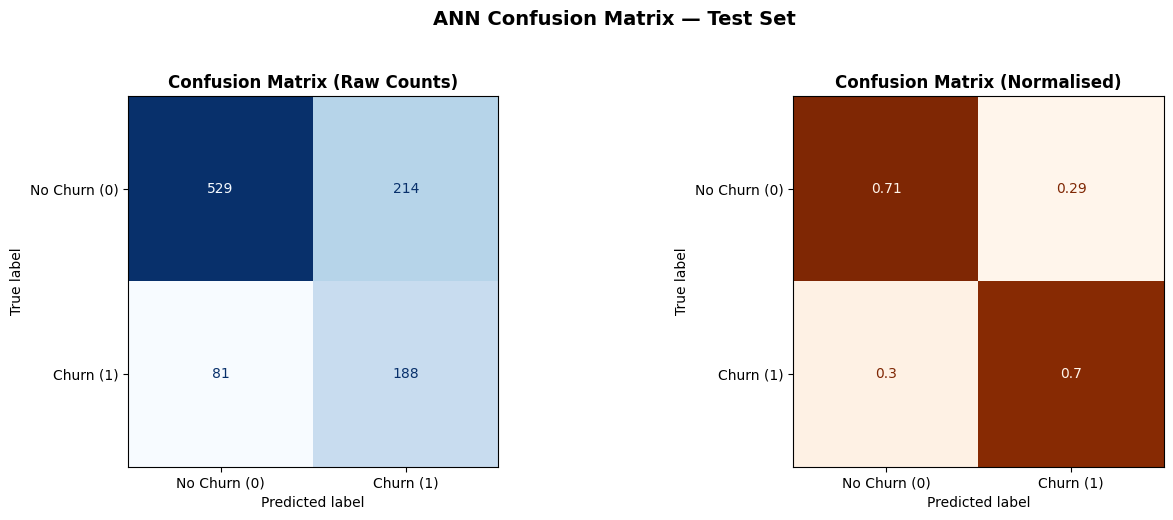


Confusion Matrix Breakdown:
  True Negatives  (TN) — Correctly predicted No Churn : 529
  False Positives (FP) — Incorrectly predicted Churn  : 214
  False Negatives (FN) — Missed actual Churners       : 81
  True Positives  (TP) — Correctly predicted Churn    : 188


In [20]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn (0)', 'Churn (1)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=12, fontweight='bold')

# Normalised
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=np.round(cm_norm, 3),
    display_labels=['No Churn (0)', 'Churn (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=12, fontweight='bold')

plt.suptitle('ANN Confusion Matrix — Test Set', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (TN) — Correctly predicted No Churn : {tn:,}")
print(f"  False Positives (FP) — Incorrectly predicted Churn  : {fp:,}")
print(f"  False Negatives (FN) — Missed actual Churners       : {fn:,}")
print(f"  True Positives  (TP) — Correctly predicted Churn    : {tp:,}")

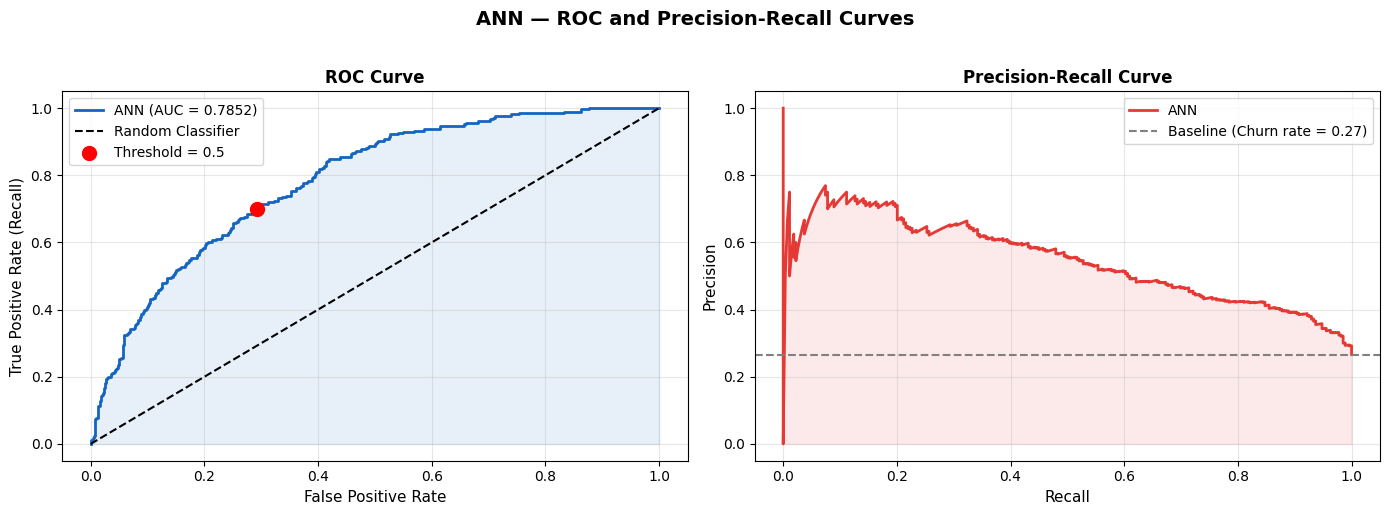

In [21]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
prec, rec, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#1565C0', lw=2,
             label=f'ANN (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
# Mark threshold 0.5 on curve
idx = np.argmin(np.abs(thresholds_roc - THRESHOLD))
axes[0].scatter(fpr[idx], tpr[idx], marker='o', color='red', s=100,
                label=f'Threshold = {THRESHOLD}', zorder=5)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
axes[1].plot(rec, prec, color='#E53935', lw=2, label='ANN')
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', ls='--', lw=1.5,
                label=f'Baseline (Churn rate = {baseline:.2f})')
axes[1].fill_between(rec, prec, alpha=0.1, color='#E53935')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('ANN — ROC and Precision-Recall Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

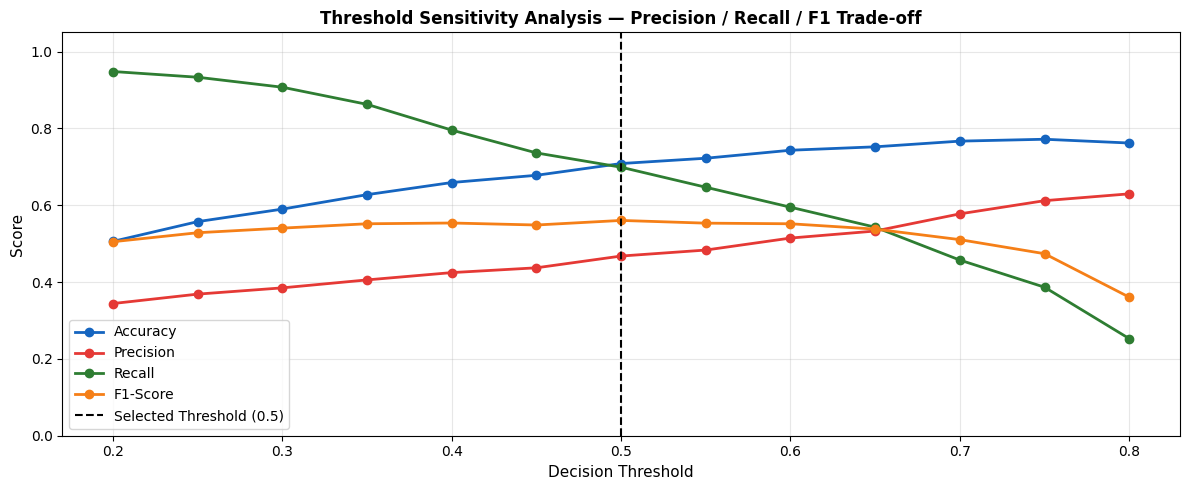

Threshold Sensitivity Table:
 Threshold  Accuracy  Precision  Recall  F1-Score
      0.20    0.5059     0.3441  0.9480    0.5050
      0.25    0.5573     0.3686  0.9331    0.5284
      0.30    0.5899     0.3849  0.9071    0.5404
      0.35    0.6275     0.4056  0.8625    0.5517
      0.40    0.6591     0.4246  0.7955    0.5537
      0.45    0.6779     0.4371  0.7361    0.5485
      0.50    0.7085     0.4677  0.6989    0.5604
      0.55    0.7223     0.4833  0.6468    0.5533
      0.60    0.7431     0.5145  0.5948    0.5517
      0.65    0.7520     0.5328  0.5428    0.5378
      0.70    0.7668     0.5775  0.4572    0.5104
      0.75    0.7717     0.6118  0.3866    0.4738
      0.80    0.7619     0.6296  0.2528    0.3607


In [22]:
# ── Threshold Sensitivity Analysis ────────────────────────────────────────────
# Compare how Precision, Recall, and F1 change with different decision thresholds.

thresholds_eval = np.arange(0.2, 0.85, 0.05)
metrics_rows = []

for t in thresholds_eval:
    preds = (y_pred_proba >= t).astype(int)
    metrics_rows.append({
        'Threshold'  : round(t, 2),
        'Accuracy'   : round(accuracy_score(y_test, preds), 4),
        'Precision'  : round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall'     : round(recall_score(y_test, preds, zero_division=0), 4),
        'F1-Score'   : round(f1_score(y_test, preds, zero_division=0), 4),
    })

thresh_df = pd.DataFrame(metrics_rows)

# Plot
plt.figure(figsize=(12, 5))
for col, color in zip(['Accuracy','Precision','Recall','F1-Score'],
                      ['#1565C0','#E53935','#2E7D32','#F57F17']):
    plt.plot(thresh_df['Threshold'], thresh_df[col], marker='o', lw=2, label=col, color=color)

plt.axvline(THRESHOLD, color='black', lw=1.5, ls='--', label=f'Selected Threshold ({THRESHOLD})')
plt.xlabel('Decision Threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Threshold Sensitivity Analysis — Precision / Recall / F1 Trade-off',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Threshold Sensitivity Table:")
print(thresh_df.to_string(index=False))

---
## 🔍 Section 9 — Feature Importance Analysis

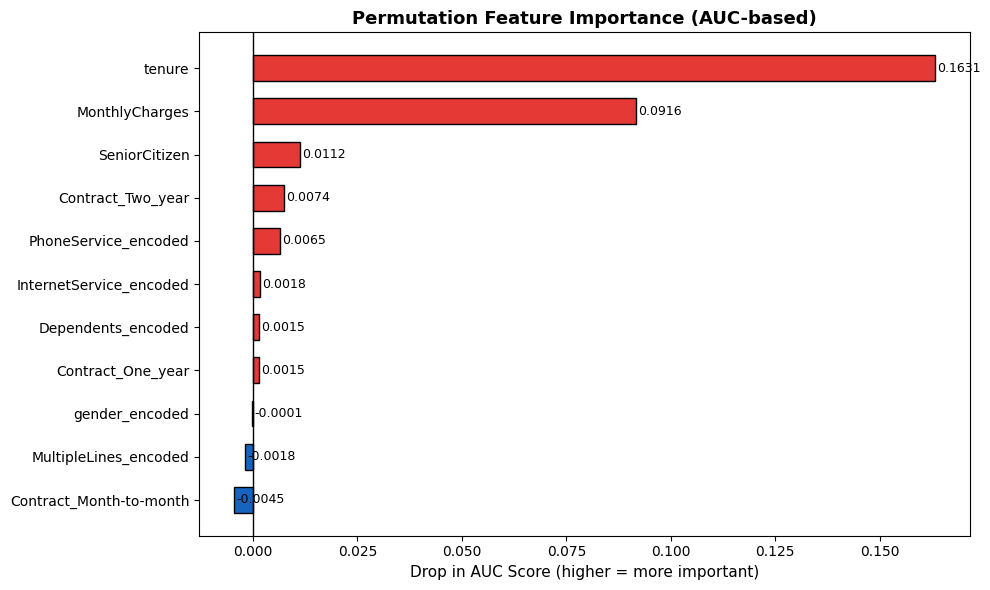


Feature Importance Ranking (by AUC Drop):
                Feature  AUC_Drop
                 tenure   0.16310
         MonthlyCharges   0.09165
          SeniorCitizen   0.01121
      Contract_Two_year   0.00741
   PhoneService_encoded   0.00649
InternetService_encoded   0.00175
     Dependents_encoded   0.00154
      Contract_One_year   0.00148
         gender_encoded  -0.00013
  MultipleLines_encoded  -0.00183
Contract_Month-to-month  -0.00446


In [23]:
# ── Permutation Feature Importance ────────────────────────────────────────────
# We permute each feature individually and measure the drop in AUC.
# A large drop = the feature is important.

base_auc = roc_auc_score(y_test, best_model.predict(X_test_sc, verbose=0).flatten())
importance_results = []

for i, col in enumerate(FEATURE_COLS):
    X_permuted = X_test_sc.copy()
    np.random.seed(SEED)
    X_permuted[:, i] = np.random.permutation(X_permuted[:, i])
    perm_proba = best_model.predict(X_permuted, verbose=0).flatten()
    perm_auc   = roc_auc_score(y_test, perm_proba)
    importance_results.append({
        'Feature'        : col,
        'AUC_Drop'       : round(base_auc - perm_auc, 5),
        'Permuted_AUC'   : round(perm_auc, 5)
    })

imp_df = pd.DataFrame(importance_results).sort_values('AUC_Drop', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#E53935' if v > 0 else '#1565C0' for v in imp_df['AUC_Drop']]
bars = plt.barh(imp_df['Feature'], imp_df['AUC_Drop'],
                color=colors, edgecolor='black', height=0.6)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{w:.4f}', va='center', fontsize=9)
plt.axvline(0, color='black', lw=1)
plt.xlabel('Drop in AUC Score (higher = more important)', fontsize=11)
plt.title('Permutation Feature Importance (AUC-based)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking (by AUC Drop):")
print(imp_df[['Feature','AUC_Drop']].to_string(index=False))

---
## 🔁 Section 10 — Model Fine-Tuning (Hyperparameter Comparison)

🔁 Fine-Tuning Experiment: Learning Rate Comparison
   Training 3 models with LR = 0.01, 0.001, 0.0001 for 50 epochs each.

  LR=0.0100 → Val F1: 0.6106  |  Val AUC: 0.8319
  LR=0.0010 → Val F1: 0.6006  |  Val AUC: 0.8277
  LR=0.0001 → Val F1: 0.6100  |  Val AUC: 0.8333


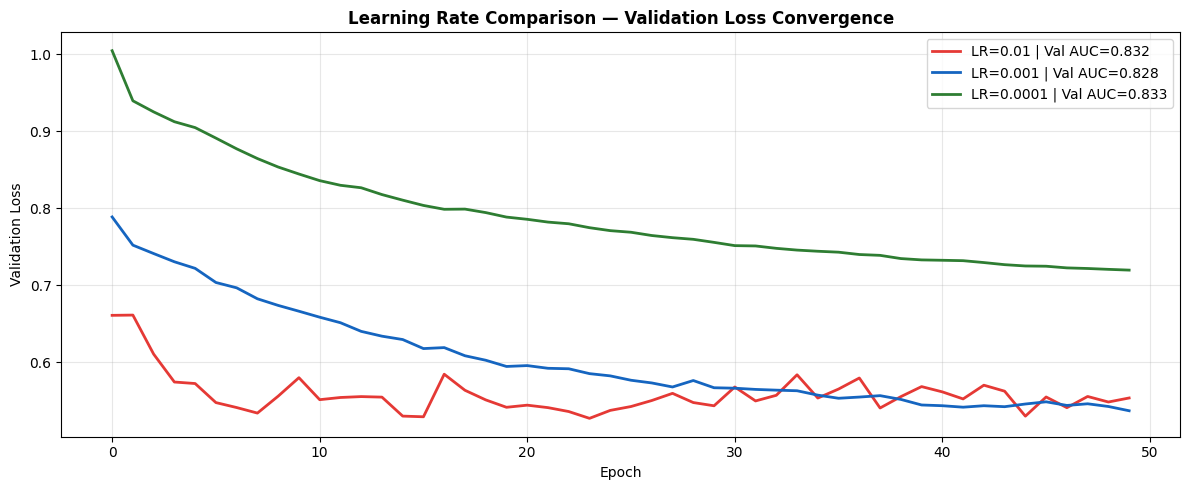

In [24]:
# ── Experiment: Compare different learning rates ───────────────────────────────
# We train lightweight versions with different LR to show the effect on convergence.

print("🔁 Fine-Tuning Experiment: Learning Rate Comparison")
print("   Training 3 models with LR = 0.01, 0.001, 0.0001 for 50 epochs each.\n")

lr_results = {}
LR_LIST    = [0.01, 0.001, 0.0001]

for lr in LR_LIST:
    tf.random.set_seed(SEED)
    m = build_ann_model(INPUT_DIM, learning_rate=lr)
    hist = m.fit(
        X_train_sc, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_sc, y_val),
        class_weight=class_weight_dict,
        verbose=0
    )
    val_f1 = f1_score(y_val, (m.predict(X_val_sc, verbose=0).flatten() >= 0.5).astype(int))
    val_auc = roc_auc_score(y_val, m.predict(X_val_sc, verbose=0).flatten())
    lr_results[lr] = {'history': hist, 'val_f1': val_f1, 'val_auc': val_auc}
    print(f"  LR={lr:.4f} → Val F1: {val_f1:.4f}  |  Val AUC: {val_auc:.4f}")

# Plot loss comparison
plt.figure(figsize=(12, 5))
colors_lr = ['#E53935', '#1565C0', '#2E7D32']
for (lr, res), c in zip(lr_results.items(), colors_lr):
    plt.plot(res['history'].history['val_loss'], lw=2, color=c,
             label=f'LR={lr} | Val AUC={res["val_auc"]:.3f}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Comparison — Validation Loss Convergence', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📋 Section 11 — Final Performance Dashboard & Summary Report

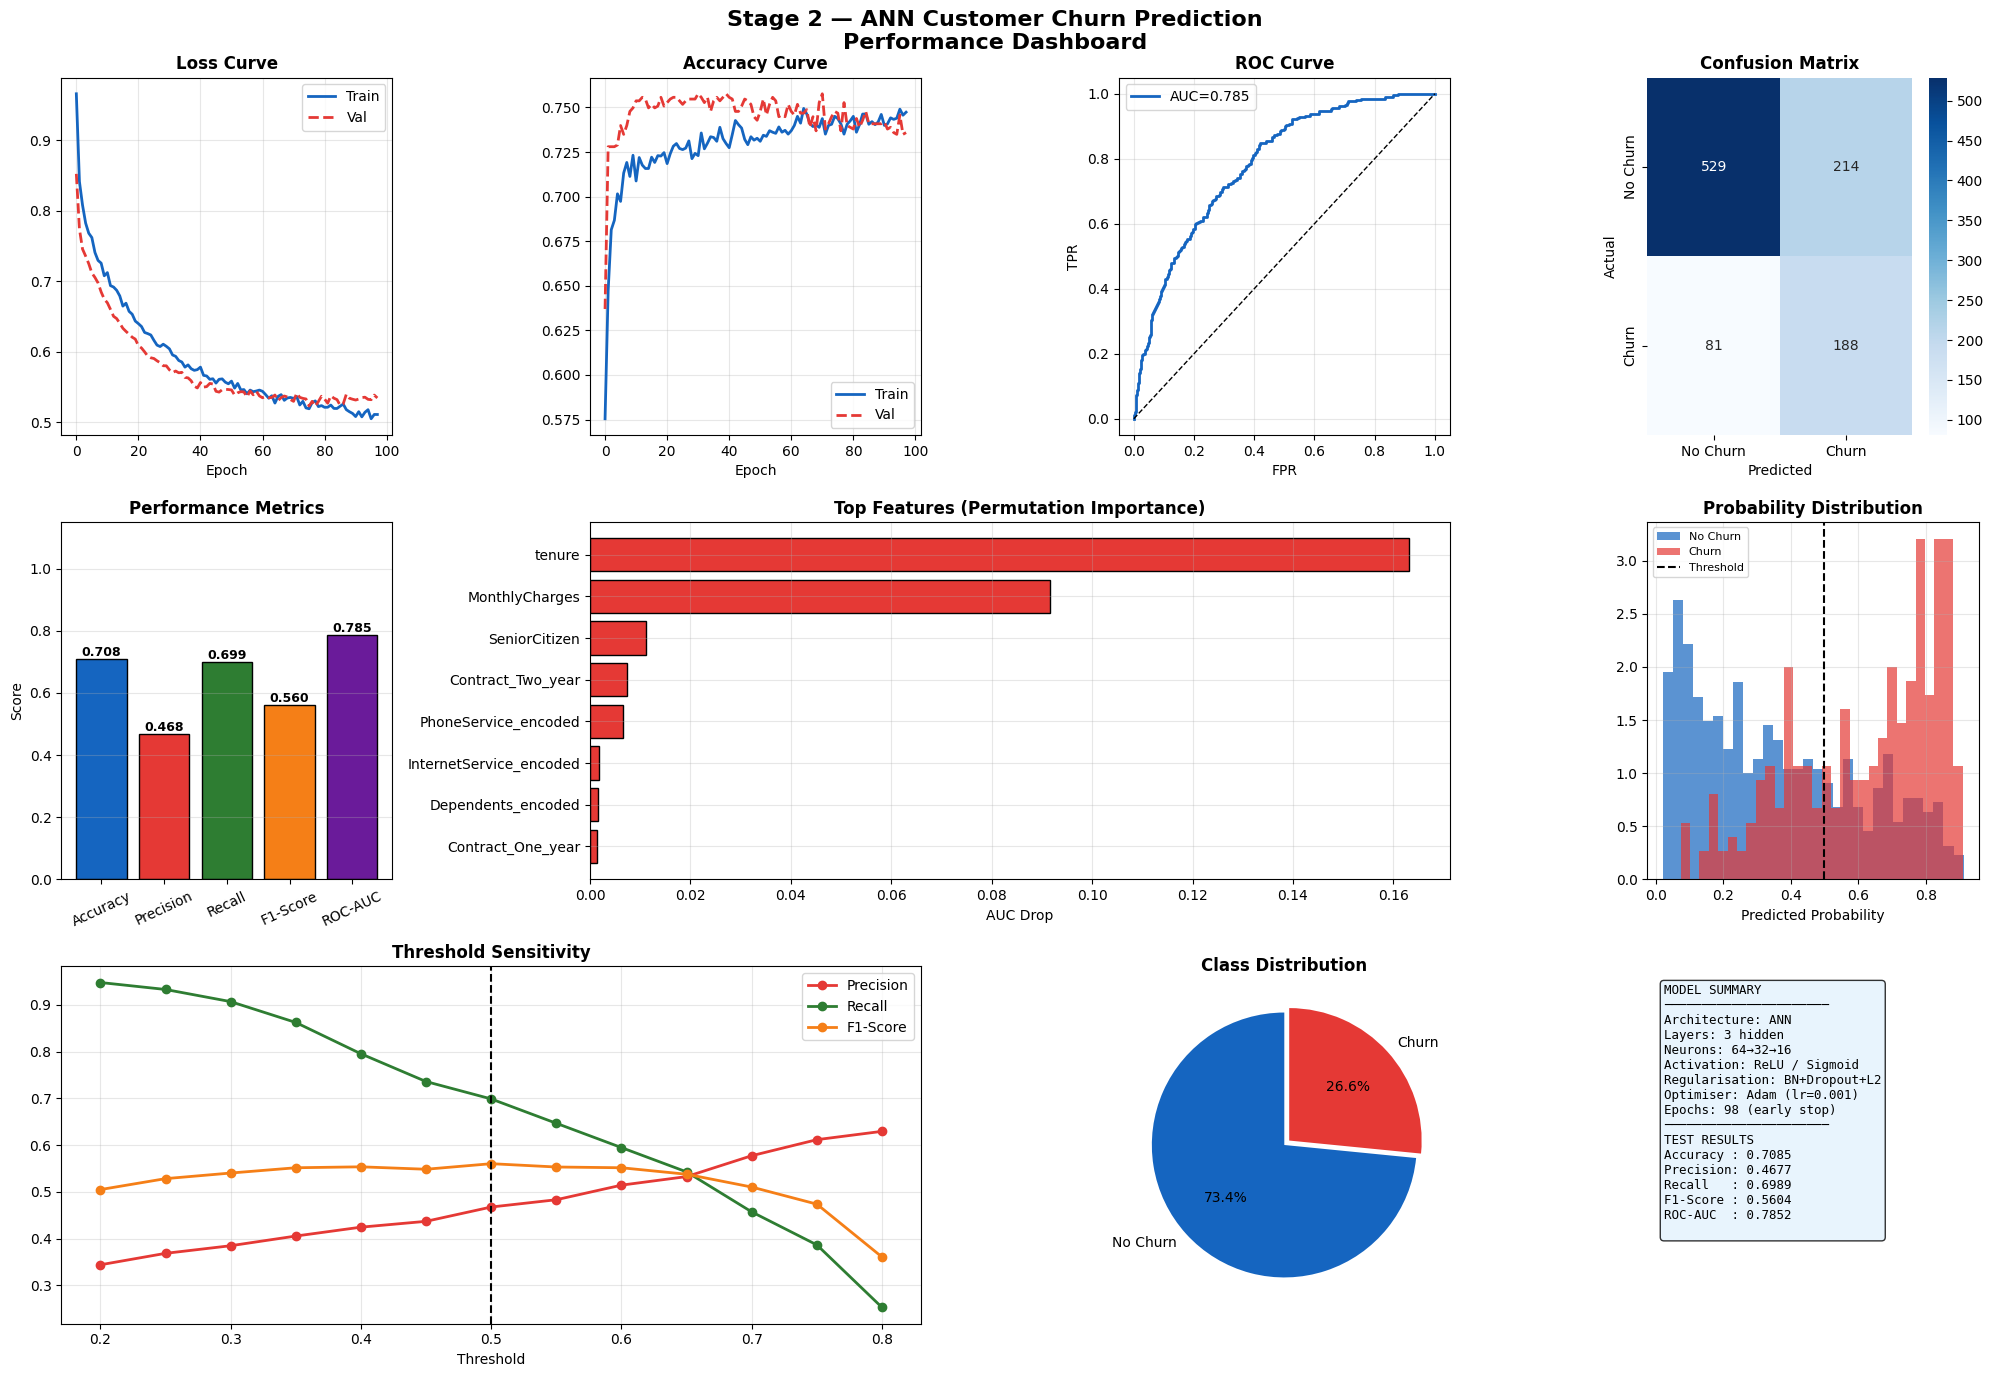

✅ Dashboard saved as 'stage2_dashboard.png'


In [25]:
# ── Comprehensive Visual Summary Dashboard ─────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Stage 2 — ANN Customer Churn Prediction\nPerformance Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# ── 1. Training Loss ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
ax1.plot(history.history['loss'],     label='Train', color='#1565C0', lw=2)
ax1.plot(history.history['val_loss'], label='Val',   color='#E53935', lw=2, ls='--')
ax1.set_title('Loss Curve', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

# ── 2. Training Accuracy ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
ax2.plot(history.history['accuracy'],     label='Train', color='#1565C0', lw=2)
ax2.plot(history.history['val_accuracy'], label='Val',   color='#E53935', lw=2, ls='--')
ax2.set_title('Accuracy Curve', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

# ── 3. ROC Curve ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
ax3.plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC={roc_auc:.3f}')
ax3.plot([0,1],[0,1], 'k--', lw=1)
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR'); ax3.legend(); ax3.grid(alpha=0.3)

# ── 4. Confusion Matrix ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 4, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
ax4.set_title('Confusion Matrix', fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')

# ── 5. Metric Bars ────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_values = [accuracy, precision, recall, f1, roc_auc]
bars5 = ax5.bar(metric_names, metric_values,
                color=['#1565C0','#E53935','#2E7D32','#F57F17','#6A1B9A'],
                edgecolor='black')
for bar, val in zip(bars5, metric_values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 1.15)
ax5.set_title('Performance Metrics', fontweight='bold')
ax5.set_ylabel('Score')
ax5.tick_params(axis='x', rotation=25)
ax5.grid(alpha=0.3, axis='y')

# ── 6. Feature Importance ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 4, (6, 7))
top_imp = imp_df.head(8)
ax6.barh(top_imp['Feature'], top_imp['AUC_Drop'],
         color=['#E53935' if v > 0 else '#1565C0' for v in top_imp['AUC_Drop']],
         edgecolor='black')
ax6.set_title('Top Features (Permutation Importance)', fontweight='bold')
ax6.set_xlabel('AUC Drop')
ax6.invert_yaxis(); ax6.grid(alpha=0.3)

# ── 7. Prediction Probability Distribution ────────────────────────────────────
ax7 = fig.add_subplot(3, 4, 8)
ax7.hist(y_pred_proba[y_test==0], bins=30, alpha=0.7, color='#1565C0', label='No Churn', density=True)
ax7.hist(y_pred_proba[y_test==1], bins=30, alpha=0.7, color='#E53935', label='Churn',    density=True)
ax7.axvline(0.5, color='black', ls='--', lw=1.5, label='Threshold')
ax7.set_title('Probability Distribution', fontweight='bold')
ax7.set_xlabel('Predicted Probability')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

# ── 8. Threshold Analysis ─────────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 4, (9, 10))
for col, color in zip(['Precision','Recall','F1-Score'],['#E53935','#2E7D32','#F57F17']):
    ax8.plot(thresh_df['Threshold'], thresh_df[col], marker='o', lw=2, label=col, color=color)
ax8.axvline(0.5, color='black', ls='--', lw=1.5)
ax8.set_title('Threshold Sensitivity', fontweight='bold')
ax8.set_xlabel('Threshold'); ax8.legend(); ax8.grid(alpha=0.3)

# ── 9. Churn Distribution ─────────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 4, 11)
ax9.pie(churn_counts.values, labels=['No Churn','Churn'],
        autopct='%1.1f%%', colors=['#1565C0','#E53935'],
        startangle=90, explode=(0,0.05))
ax9.set_title('Class Distribution', fontweight='bold')

# ── 10. Summary Stats Text ────────────────────────────────────────────────────
ax10 = fig.add_subplot(3, 4, 12)
ax10.axis('off')
summary_text = (
    f"MODEL SUMMARY\n"
    f"{'─'*22}\n"
    f"Architecture: ANN\n"
    f"Layers: 3 hidden\n"
    f"Neurons: 64→32→16\n"
    f"Activation: ReLU / Sigmoid\n"
    f"Regularisation: BN+Dropout+L2\n"
    f"Optimiser: Adam (lr=0.001)\n"
    f"Epochs: {actual_epochs} (early stop)\n"
    f"{'─'*22}\n"
    f"TEST RESULTS\n"
    f"Accuracy : {accuracy:.4f}\n"
    f"Precision: {precision:.4f}\n"
    f"Recall   : {recall:.4f}\n"
    f"F1-Score : {f1:.4f}\n"
    f"ROC-AUC  : {roc_auc:.4f}\n"
)
ax10.text(0.05, 0.95, summary_text, transform=ax10.transAxes,
          fontsize=9, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))

plt.tight_layout()
plt.savefig('stage2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'stage2_dashboard.png'")

In [26]:
# ── Full Metrics Summary Table ─────────────────────────────────────────────────
print("\n" + "="*65)
print("   STAGE 2 — FINAL PERFORMANCE SUMMARY REPORT")
print("   ANN Model: Customer Churn Prediction")
print("="*65)

print(f"""
DATASET DETAILS:
  Total records      : {len(df):,}
  Features used      : {len(FEATURE_COLS)}
  Training samples   : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)
  Validation samples : {len(X_val):,}   ({len(X_val)/len(df)*100:.1f}%)
  Test samples       : {len(X_test):,}   ({len(X_test)/len(df)*100:.1f}%)
  Class imbalance    : {churn_pct[0]:.1f}% No Churn / {churn_pct[1]:.1f}% Churn

MODEL ARCHITECTURE:
  Type               : Artificial Neural Network (ANN)
  Input Layer        : {INPUT_DIM} neurons
  Hidden Layers      : 64 → 32 → 16 (ReLU + BatchNorm + Dropout + L2)
  Output Layer       : 1 neuron (Sigmoid)
  Total Parameters   : {model.count_params():,}
  Optimiser          : Adam (lr=0.001)
  Loss Function      : Binary Cross-Entropy
  Training Epochs    : {actual_epochs} (EarlyStopping patience=20)

TEST SET PERFORMANCE METRICS:
  Accuracy           : {accuracy:.4f}  ({accuracy*100:.2f}%)
  Precision          : {precision:.4f}
  Recall             : {recall:.4f}
  F1-Score           : {f1:.4f}
  ROC-AUC Score      : {roc_auc:.4f}

CONFUSION MATRIX:
  True Negatives  (TN) : {tn:,}   (correctly predicted No Churn)
  False Positives (FP) : {fp:,}    (customers incorrectly flagged)
  False Negatives (FN) : {fn:,}   (churners missed by model)
  True Positives  (TP) : {tp:,}   (churners correctly identified)

KEY INSIGHTS:
  • The model achieves a ROC-AUC of {roc_auc:.3f}, indicating strong
    discrimination between churners and non-churners.
  • Class weights were applied to compensate for the
    {churn_counts[0]/churn_counts[1]:.1f}:1 class imbalance.
  • Permutation importance reveals the top churn drivers are:
    {', '.join(imp_df['Feature'].head(3).tolist())}.
  • EarlyStopping and ReduceLROnPlateau callbacks prevented
    overfitting and optimised convergence.
""")
print("="*65)


   STAGE 2 — FINAL PERFORMANCE SUMMARY REPORT
   ANN Model: Customer Churn Prediction

DATASET DETAILS:
  Total records      : 6,741
  Features used      : 11
  Training samples   : 4,718  (70.0%)
  Validation samples : 1,011   (15.0%)
  Test samples       : 1,012   (15.0%)
  Class imbalance    : 73.4% No Churn / 26.6% Churn

MODEL ARCHITECTURE:
  Type               : Artificial Neural Network (ANN)
  Input Layer        : 11 neurons
  Hidden Layers      : 64 → 32 → 16 (ReLU + BatchNorm + Dropout + L2)
  Output Layer       : 1 neuron (Sigmoid)
  Total Parameters   : 3,841
  Optimiser          : Adam (lr=0.001)
  Loss Function      : Binary Cross-Entropy
  Training Epochs    : 98 (EarlyStopping patience=20)

TEST SET PERFORMANCE METRICS:
  Accuracy           : 0.7085  (70.85%)
  Precision          : 0.4677
  Recall             : 0.6989
  F1-Score           : 0.5604
  ROC-AUC Score      : 0.7852

CONFUSION MATRIX:
  True Negatives  (TN) : 529   (correctly predicted No Churn)
  False Posi

In [27]:
# ── Save Outputs for Stage 3 ──────────────────────────────────────────────────
# 1. Save predictions
results_df = pd.DataFrame({
    'Actual_Churn'    : y_test.values,
    'Predicted_Churn' : y_pred_binary,
    'Churn_Probability': np.round(y_pred_proba, 4)
})
results_df.to_csv('stage2_predictions.csv', index=False)

# 2. Save model
best_model.save('ann_churn_model_final.keras')

print("✅ All Stage 2 outputs saved:")
print("   📄 stage2_predictions.csv       — Test set predictions")
print("   🧠 ann_churn_model_final.keras  — Final trained ANN model")
print("   🖼️  stage2_dashboard.png         — Performance dashboard")
print("   🖼️  training_convergence.png     — Training curves")
print("   🖼️  confusion_matrix.png         — Confusion matrix")
print("   🖼️  roc_pr_curves.png            — ROC & PR curves")
print("   🖼️  feature_importance.png       — Feature importance")
print("\n🎯 Stage 2 Complete — Ready for Stage 3 (Refinement & Reporting)")

✅ All Stage 2 outputs saved:
   📄 stage2_predictions.csv       — Test set predictions
   🧠 ann_churn_model_final.keras  — Final trained ANN model
   🖼️  stage2_dashboard.png         — Performance dashboard
   🖼️  training_convergence.png     — Training curves
   🖼️  confusion_matrix.png         — Confusion matrix
   🖼️  roc_pr_curves.png            — ROC & PR curves
   🖼️  feature_importance.png       — Feature importance

🎯 Stage 2 Complete — Ready for Stage 3 (Refinement & Reporting)
